## 🗄️ SQL Analytics
#### Bank Loan Default Analytics

---

> **Notebook 4 of 5**  
> **Goal:** Load processed data into a SQLite database, run SQL queries to extract business insights, and build an analytics layer for the Streamlit dashboard.  
> **Input:** `data/processed/engineered_data.csv`  
> **Output:** `data/processed/bankloan.db` (SQLite database)

### Step 1 — Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import sqlalchemy
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', lambda x: '%.3f' % x)
pd.set_option('display.max_columns', None)

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


### Step 2 — Load Processed Data & Create SQLite Database
Loading the engineered dataset and pushing it into a SQLite database for SQL-based analysis.

In [2]:
# Load processed data
df = pd.read_csv('../data/processed/engineered_data.csv')
print(f"✅ Data loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

# Create SQLite engine
engine = create_engine('sqlite:///../data/processed/bankloan.db')

# Push data to SQLite as a table
df.to_sql('loan_applications', engine, if_exists='replace', index=False)
print(f"✅ Database created: data/processed/bankloan.db")
print(f"✅ Table created   : loan_applications ({df.shape[0]:,} rows)")

✅ Data loaded: 307,511 rows × 78 columns
✅ Database created: data/processed/bankloan.db
✅ Table created   : loan_applications (307,511 rows)


### Step 3 — Verify Database Connection

In [3]:
# Connect and verify
conn = sqlite3.connect('../data/processed/bankloan.db')

# Check tables
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(f"Tables in database: {tables['name'].tolist()}")

# Check row count
count = pd.read_sql("SELECT COUNT(*) as total_rows FROM loan_applications", conn)
print(f"Total rows        : {count['total_rows'][0]:,}")

# Preview
preview = pd.read_sql("SELECT * FROM loan_applications LIMIT 5", conn)
preview.head()

Tables in database: ['loan_applications']
Total rows        : 307,511


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_2,EXT_SOURCE_3,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS,YEARS_EMPLOYED,YEARS_ID_PUBLISH,YEARS_REGISTRATION,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_GOODS_RATIO,INCOME_PER_PERSON,EMPLOYMENT_AGE_RATIO
0,100002,1,0,1,0,1,0,202500.000,406597.500,24700.500,351000.000,6,7,4,3,1,0.019,1,1,0,1,1,0,8,1.000,2,2,6,10,0,0,0,0,0,0,5,0.263,0.139,2.000,2.000,2.000,2.000,-1134.000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,1.000,25,1.745,5.808,9.995,2.008,0.122,1.158,202500.000,0.070
1,100003,0,0,0,0,0,0,270000.000,1293502.500,35698.500,1129500.000,1,4,1,1,1,0.004,1,1,0,1,1,0,3,2.000,1,1,1,11,0,0,0,0,0,0,39,0.622,NaN,1.000,0.000,1.000,0.000,-828.000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000,45,3.255,0.797,3.249,4.791,0.132,1.145,135000.000,0.072
2,100004,0,1,1,1,1,0,67500.000,135000.000,6750.000,135000.000,6,7,4,3,1,0.010,1,1,1,1,1,0,8,1.000,2,2,1,9,0,0,0,0,0,0,11,0.556,0.730,0.000,0.000,0.000,0.000,-815.000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000,52,0.616,6.934,11.671,2.000,0.100,1.000,67500.000,0.012
3,100006,0,0,0,0,1,0,135000.000,312682.500,29686.500,297000.000,6,7,4,0,1,0.008,1,1,0,1,0,0,8,2.000,2,2,6,17,0,0,0,0,0,0,5,0.650,NaN,2.000,0.000,2.000,0.000,-617.000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,52,8.326,6.677,26.940,2.316,0.220,1.053,67500.000,0.160
4,100007,0,0,1,0,1,0,121500.000,513000.000,21865.500,513000.000,6,7,4,3,1,0.029,1,1,0,1,0,0,3,1.000,2,2,4,11,0,0,0,0,1,1,37,0.323,NaN,0.000,0.000,0.000,0.000,-1106.000,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000,54,8.323,9.474,11.811,4.222,0.180,1.000,121500.000,0.154


### Step 4 — SQL Query 1: Overall Default Rate

In [4]:
query1 = """
SELECT 
    COUNT(*) as total_applications,
    SUM(TARGET) as total_defaults,
    ROUND(AVG(TARGET) * 100, 2) as default_rate_pct,
    ROUND(AVG(AMT_CREDIT), 2) as avg_credit_amount,
    ROUND(AVG(AMT_INCOME_TOTAL), 2) as avg_income
FROM loan_applications
"""

result1 = pd.read_sql(query1, conn)
print("📊 Overall Loan Portfolio Summary:")
print(result1.to_string(index=False))

📊 Overall Loan Portfolio Summary:
 total_applications  total_defaults  default_rate_pct  avg_credit_amount  avg_income
             307511           24825             8.070         599026.000  168797.920


### Step 5 — SQL Query 2: Default Rate by Gender

In [5]:
query2 = """
SELECT
    CODE_GENDER,
    COUNT(*) as total_applications,
    SUM(TARGET) as total_defaults,
    ROUND(AVG(TARGET) * 100, 2) as default_rate_pct,
    ROUND(AVG(AMT_INCOME_TOTAL), 2) as avg_income,
    ROUND(AVG(AMT_CREDIT), 2) as avg_credit
FROM loan_applications
GROUP BY CODE_GENDER
ORDER BY default_rate_pct DESC
"""

result2 = pd.read_sql(query2, conn)
print("📊 Default Rate by Gender:")
print(result2.to_string(index=False))

📊 Default Rate by Gender:
 CODE_GENDER  total_applications  total_defaults  default_rate_pct  avg_income  avg_credit
           1              105059           10655            10.140  193396.480  611095.200
           0              202448           14170             7.000  156032.310  592766.720
           2                   4               0             0.000  186750.000  399375.000


### Step 6 — SQL Query 3: Default Rate by Income Type

In [6]:
query3 = """
SELECT
    NAME_INCOME_TYPE,
    COUNT(*) as total_applications,
    SUM(TARGET) as total_defaults,
    ROUND(AVG(TARGET) * 100, 2) as default_rate_pct,
    ROUND(AVG(AMT_INCOME_TOTAL), 2) as avg_income
FROM loan_applications
GROUP BY NAME_INCOME_TYPE
ORDER BY default_rate_pct DESC
"""

result3 = pd.read_sql(query3, conn)
print("📊 Default Rate by Income Type:")
print(result3.to_string(index=False))

📊 Default Rate by Income Type:
 NAME_INCOME_TYPE  total_applications  total_defaults  default_rate_pct  avg_income
                2                   5               2            40.000  140400.000
                6                  22               8            36.360  110536.360
                7              158774           15224             9.590  163169.890
                1               71617            5360             7.480  202955.330
                4               21703            1249             5.750  179737.970
                3               55362            2982             5.390  136401.290
                5                  18               0             0.000  170500.000
                0                  10               0             0.000  652500.000


### Step 7 — SQL Query 4: Risk Segmentation by Credit Amount
Segmenting loans into risk buckets based on credit amount.

In [7]:
query4 = """
SELECT
    CASE
        WHEN AMT_CREDIT < 200000  THEN 'Low (< 200K)'
        WHEN AMT_CREDIT < 500000  THEN 'Medium (200K–500K)'
        WHEN AMT_CREDIT < 1000000 THEN 'High (500K–1M)'
        ELSE 'Very High (> 1M)'
    END as credit_segment,
    COUNT(*) as total_applications,
    SUM(TARGET) as total_defaults,
    ROUND(AVG(TARGET) * 100, 2) as default_rate_pct,
    ROUND(AVG(AMT_CREDIT), 2) as avg_credit
FROM loan_applications
GROUP BY credit_segment
ORDER BY default_rate_pct DESC
"""

result4 = pd.read_sql(query4, conn)
print("📊 Risk Segmentation by Credit Amount:")
print(result4.to_string(index=False))

📊 Risk Segmentation by Credit Amount:
    credit_segment  total_applications  total_defaults  default_rate_pct  avg_credit
Medium (200K–500K)              113189           10115             8.940  331074.770
    High (500K–1M)              108193            9288             8.580  702286.770
      Low (< 200K)               36144            2490             6.890  142385.760
  Very High (> 1M)               49985            2932             5.870 1312476.910


### Step 8 — SQL Query 5: Default Rate by Age Group

In [8]:
query5 = """
SELECT
    CASE
        WHEN AGE_YEARS < 25 THEN 'Young (< 25)'
        WHEN AGE_YEARS < 35 THEN 'Young Adult (25–35)'
        WHEN AGE_YEARS < 45 THEN 'Middle Age (35–45)'
        WHEN AGE_YEARS < 55 THEN 'Senior Adult (45–55)'
        ELSE 'Senior (55+)'
    END as age_group,
    COUNT(*) as total_applications,
    SUM(TARGET) as total_defaults,
    ROUND(AVG(TARGET) * 100, 2) as default_rate_pct,
    ROUND(AVG(AMT_INCOME_TOTAL), 2) as avg_income
FROM loan_applications
GROUP BY age_group
ORDER BY default_rate_pct DESC
"""

result5 = pd.read_sql(query5, conn)
print("📊 Default Rate by Age Group:")
print(result5.to_string(index=False))

📊 Default Rate by Age Group:
           age_group  total_applications  total_defaults  default_rate_pct  avg_income
        Young (< 25)               12150            1496            12.310  145340.570
 Young Adult (25–35)               72289            7716            10.670  172035.880
  Middle Age (35–45)               84276            7083             8.400  180498.250
Senior Adult (45–55)               70069            4946             7.060  175456.240
        Senior (55+)               68727            3584             5.210  148403.290


### Step 9 — SQL Query 6: Top 10 Riskiest Loan Profiles
Finding the combination of features that produces the highest default rate.

In [9]:
query6 = """
SELECT
    NAME_CONTRACT_TYPE,
    NAME_INCOME_TYPE,
    NAME_EDUCATION_TYPE,
    COUNT(*) as total_applications,
    SUM(TARGET) as total_defaults,
    ROUND(AVG(TARGET) * 100, 2) as default_rate_pct,
    ROUND(AVG(AMT_CREDIT), 2) as avg_credit
FROM loan_applications
GROUP BY NAME_CONTRACT_TYPE, NAME_INCOME_TYPE, NAME_EDUCATION_TYPE
HAVING total_applications > 100
ORDER BY default_rate_pct DESC
LIMIT 10
"""

result6 = pd.read_sql(query6, conn)
print("📊 Top 10 Riskiest Loan Profiles:")
print(result6.to_string(index=False))

📊 Top 10 Riskiest Loan Profiles:
 NAME_CONTRACT_TYPE  NAME_INCOME_TYPE  NAME_EDUCATION_TYPE  total_applications  total_defaults  default_rate_pct  avg_credit
                  0                 7                    3                1611             239            14.840  534124.700
                  0                 1                    3                 435              54            12.410  574455.230
                  0                 7                    4              106773           11570            10.840  589278.050
                  1                 7                    3                 114              12            10.530  227171.050
                  0                 7                    2                4874             477             9.790  578877.740
                  0                 1                    4               39632            3539             8.930  665468.330
                  0                 1                    2                2972             2

### Step 10 — SQL Query 7: Loan Portfolio Health Summary
A high level executive summary of the entire loan portfolio.

In [10]:
query7 = """
SELECT
    COUNT(*) as total_loans,
    SUM(TARGET) as total_defaults,
    COUNT(*) - SUM(TARGET) as total_repaid,
    ROUND(AVG(TARGET) * 100, 2) as overall_default_rate,
    ROUND(SUM(AMT_CREDIT), 2) as total_credit_disbursed,
    ROUND(AVG(AMT_CREDIT), 2) as avg_loan_size,
    ROUND(MIN(AMT_CREDIT), 2) as min_loan_size,
    ROUND(MAX(AMT_CREDIT), 2) as max_loan_size,
    ROUND(AVG(AMT_INCOME_TOTAL), 2) as avg_applicant_income,
    ROUND(AVG(AGE_YEARS), 0) as avg_applicant_age
FROM loan_applications
"""

result7 = pd.read_sql(query7, conn)
print("📊 Loan Portfolio Health Summary:")
for col in result7.columns:
    print(f"   {col:<30}: {result7[col][0]:,}")

📊 Loan Portfolio Health Summary:
   total_loans                   : 307,511
   total_defaults                : 24,825
   total_repaid                  : 282,686
   overall_default_rate          : 8.07
   total_credit_disbursed        : 184,207,084,195.5
   avg_loan_size                 : 599,026.0
   min_loan_size                 : 45,000.0
   max_loan_size                 : 4,050,000.0
   avg_applicant_income          : 168,797.92
   avg_applicant_age             : 43.0


### Step 11 — Visualizing SQL Results

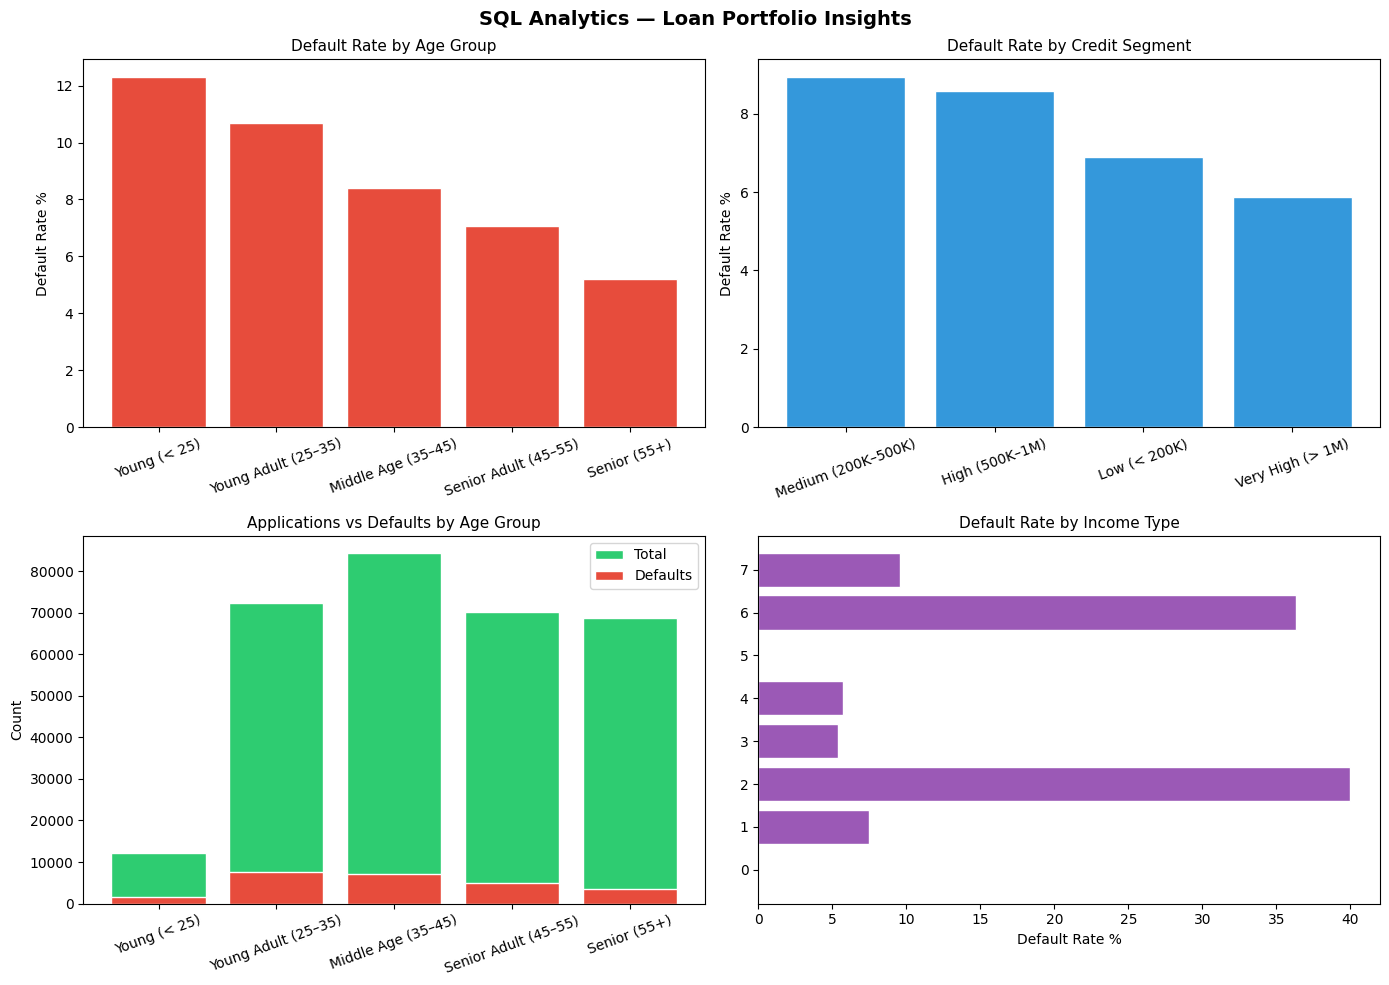

✅ Chart saved to images/sql_analytics.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Default rate by age group
axes[0][0].bar(result5['age_group'], result5['default_rate_pct'],
               color='#e74c3c', edgecolor='white')
axes[0][0].set_title('Default Rate by Age Group', fontsize=11)
axes[0][0].set_ylabel('Default Rate %')
axes[0][0].tick_params(axis='x', rotation=20)

# Default rate by credit segment
axes[0][1].bar(result4['credit_segment'], result4['default_rate_pct'],
               color='#3498db', edgecolor='white')
axes[0][1].set_title('Default Rate by Credit Segment', fontsize=11)
axes[0][1].set_ylabel('Default Rate %')
axes[0][1].tick_params(axis='x', rotation=20)

# Total applications vs defaults by age group
axes[1][0].bar(result5['age_group'], result5['total_applications'],
               color='#2ecc71', edgecolor='white', label='Total')
axes[1][0].bar(result5['age_group'], result5['total_defaults'],
               color='#e74c3c', edgecolor='white', label='Defaults')
axes[1][0].set_title('Applications vs Defaults by Age Group', fontsize=11)
axes[1][0].set_ylabel('Count')
axes[1][0].tick_params(axis='x', rotation=20)
axes[1][0].legend()

# Default rate by income type
axes[1][1].barh(result3['NAME_INCOME_TYPE'], result3['default_rate_pct'],
                color='#9b59b6', edgecolor='white')
axes[1][1].set_title('Default Rate by Income Type', fontsize=11)
axes[1][1].set_xlabel('Default Rate %')

plt.suptitle('SQL Analytics — Loan Portfolio Insights', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/sql_analytics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to images/sql_analytics.png")

In [12]:
# Close connection
conn.close()
print("✅ Database connection closed")

✅ Database connection closed


### Step 12 — SQL Analytics Summary

In [13]:
print("=" * 55)
print("        SQL ANALYTICS SUMMARY")
print("=" * 55)
print(f"\n🗄️  Database         : data/processed/bankloan.db")
print(f"📋 Table            : loan_applications")
print(f"📊 Total Records    : {df.shape[0]:,}")
print(f"\n✅ Queries Completed:")
print(f"   → Overall default rate")
print(f"   → Default rate by gender")
print(f"   → Default rate by income type")
print(f"   → Risk segmentation by credit amount")
print(f"   → Default rate by age group")
print(f"   → Top 10 riskiest loan profiles")
print(f"   → Loan portfolio health summary")
print(f"\n✅ SQL Analytics Complete — Moving to Model Evaluation")
print("=" * 55)

        SQL ANALYTICS SUMMARY

🗄️  Database         : data/processed/bankloan.db
📋 Table            : loan_applications
📊 Total Records    : 307,511

✅ Queries Completed:
   → Overall default rate
   → Default rate by gender
   → Default rate by income type
   → Risk segmentation by credit amount
   → Default rate by age group
   → Top 10 riskiest loan profiles
   → Loan portfolio health summary

✅ SQL Analytics Complete — Moving to Model Evaluation
